<a href="https://colab.research.google.com/github/Arjun-08/DNA-Language-Models-for-Mutation-Classification-Identifying-Benign-and-Harmful-VariantS/blob/main/DNA_CNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython pandas cyvcf2 tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
CLINVAR_URL = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz"
GENOME_URL = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz"

!wget $CLINVAR_URL -O clinvar.vcf.gz
!wget $GENOME_URL -O GRCh38.fna.gz
!gunzip clinvar.vcf.gz
!gunzip GRCh38.fna.gz

--2025-03-27 14:40:07--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149796777 (143M) [application/x-gzip]
Saving to: ‘clinvar.vcf.gz’

clinvar.vcf.gz      100%[===================>] 142.86M  73.0MB/s    in 2.0s    

2025-03-27 14:40:09 (73.0 MB/s) - ‘clinvar.vcf.gz’ saved [149796777/149796777]

--2025-03-27 14:40:09--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response

In [ ]:
from cyvcf2 import VCF
from Bio import SeqIO
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split



In [ ]:
VCF_PATH = "clinvar.vcf"
FASTA_PATH = "GRCh38.fna"
WINDOW = 50
MAX_VARIANTS = 5000

In [ ]:
# Load genome FASTA
print("Loading GRCh38 genome...")
genome = SeqIO.to_dict(SeqIO.parse(FASTA_PATH, "fasta"))
genome = {k.replace('chr', ''): v for k, v in genome.items()}

Loading GRCh38 genome...


In [ ]:
# Function to check for SNV
def is_snv(variant):
    return len(variant.REF) == 1 and all(len(alt) == 1 for alt in variant.ALT)

In [ ]:
# Parse ClinVar with both REF and ALT sequences
print("Parsing ClinVar VCF with REF and ALT sequences...")
ref_sequences = []
alt_sequences = []
labels = []

vcf = VCF(VCF_PATH)

for variant in tqdm(vcf):
    sig = variant.INFO.get("CLNSIG")
    if not isinstance(sig, str):
        continue

    if "Pathogenic" in sig:
        label = 1
    elif "Benign" in sig:
        label = 0
    else:
        continue

    if not is_snv(variant):
        continue

    chrom = variant.CHROM
    pos = variant.POS - 1
    ref = variant.REF
    if not variant.ALT:
        continue
    alt = variant.ALT[0]

    if chrom not in genome:
        continue

    seq_record = genome[chrom]
    start = pos - WINDOW
    end = pos + WINDOW + 1
    if start < 0 or end > len(seq_record.seq):
        continue

    ref_seq = seq_record.seq[start:end].upper()
    if len(ref_seq) != 2 * WINDOW + 1:
        continue

    center = WINDOW
    if ref_seq[center] != ref:
        continue

    # ALT sequence with the alternate allele inserted
    alt_seq = ref_seq[:center] + alt + ref_seq[center + 1:]

    ref_sequences.append(str(ref_seq))
    alt_sequences.append(str(alt_seq))
    labels.append(label)

    if len(ref_sequences) >= MAX_VARIANTS:
        break

# Save to CSV
df = pd.DataFrame({
    "ref": ref_sequences,
    "sequence": alt_sequences,  # Keep this for backward compatibility
    "label": labels
})
df.to_csv("dna_variants.csv", index=False)
print(f"Saved dataset with {len(df)} variants (REF and ALT) to dna_variants.csv")


Parsing ClinVar VCF with REF and ALT sequences...


53720it [00:00, 117034.33it/s]


Saved dataset with 5000 variants (REF and ALT) to dna_variants.csv


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import random
import json

In [ ]:
# One-hot encoding

def one_hot_encode(seq):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    one_hot = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq.upper()):
        if base in mapping:
            one_hot[mapping[base], i] = 1.0
    return one_hot

In [ ]:
# Dataset with ref and alt sequences concatenated and delta_ll
class DnaPairDataset(Dataset):
    def __init__(self, ref_seqs, alt_seqs, labels, delta_lls=None):
        self.sequences = [np.concatenate((one_hot_encode(r), one_hot_encode(a)), axis=1) for r, a in zip(ref_seqs, alt_seqs)]
        self.labels = labels
        self.delta_lls = delta_lls

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        delta_ll = torch.tensor(self.delta_lls[idx], dtype=torch.float32) if self.delta_lls else torch.tensor(0.0)
        return seq, label, delta_ll


In [ ]:
# CNN model
class DnaCNN(nn.Module):
    def __init__(self, input_len):
        super(DnaCNN, self).__init__()
        self.conv1 = nn.Conv1d(4, 64, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3)
        self.pool2 = nn.MaxPool1d(2)
        conv_output_size = ((input_len - 4) // 2 - 2) // 2
        self.fc1 = nn.Linear(128 * conv_output_size, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze()

In [ ]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, labels, _ in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = (outputs > 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    accuracy = total_correct / total_samples
    return total_loss / len(dataloader), accuracy


In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    preds, trues, delta_lls = [], [], []
    with torch.no_grad():
        for inputs, labels, delta in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds.extend(outputs.cpu().numpy())
            trues.extend(labels.cpu().numpy())
            delta_lls.extend(delta.numpy())

    pred_labels = [1 if p > 0.5 else 0 for p in preds]
    precision, recall, f1, _ = precision_recall_fscore_support(trues, pred_labels, average='binary')
    print("\nEvaluation Report:")
    print(classification_report(trues, pred_labels, digits=4))
    print("ROC AUC Score: {:.4f}".format(roc_auc_score(trues, preds)))
    print("Test Accuracy: {:.2f}%".format(accuracy_score(trues, pred_labels) * 100))
    print("Precision: {:.4f}, Recall: {:.4f}, F1 Score: {:.4f}".format(precision, recall, f1))
    return preds, trues, delta_lls

In [ ]:
def main():
    df = pd.read_csv("dna_variants.csv")
    ref_seqs = df['ref'].tolist()
    alt_seqs = df['sequence'].tolist()
    labels = df['label'].tolist()

    # Load delta log-likelihood scores from GPN (if available)
    try:
        with open("delta_ll_scores.json") as f:
            delta_lls = json.load(f)
    except FileNotFoundError:
        delta_lls = [0.0] * len(labels)

    print("Class distribution:", Counter(labels))

    # Split data
    dataset = DnaPairDataset(ref_seqs, alt_seqs, labels, delta_lls)
    total_size = len(dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)

    input_len = len(ref_seqs[0]) * 2
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DnaCNN(input_len).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_auc = 0
    patience = 3
    no_improve = 0
    train_losses, val_aucs = [], []

    for epoch in range(15):
        loss, acc = train_model(model, train_loader, criterion, optimizer, device)
        preds, trues, _ = evaluate_model(model, val_loader, device)
        auc = roc_auc_score(trues, preds)
        train_losses.append(loss)
        val_aucs.append(auc)

        print(f"Epoch {epoch+1} - Loss: {loss:.4f}, Val AUC: {auc:.4f}")

        if auc > best_val_auc:
            best_val_auc = auc
            torch.save(model.state_dict(), "best_model.pth")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered.")
                break

    # Load best model and evaluate on test set
    model.load_state_dict(torch.load("best_model.pth"))
    print("\nFinal Test Evaluation:")
    preds, trues, delta_lls = evaluate_model(model, test_loader, device)

    # Combine CNN + GPN delta_ll using logistic regression
    X_ensemble = np.vstack([preds, delta_lls]).T
    clf = LogisticRegression()
    clf.fit(X_ensemble, trues)
    final_preds = clf.predict_proba(X_ensemble)[:, 1]
    final_labels = (final_preds > 0.5).astype(int)

    print("\nEnsemble Evaluation:")
    print(classification_report(trues, final_labels, digits=4))
    print("Ensemble ROC AUC Score: {:.4f}".format(roc_auc_score(trues, final_preds)))

    # Save training history and predictions for plotting
    torch.save({
        "train_losses": train_losses,
        "val_aucs": val_aucs,
        "cnn_preds": preds,
        "cnn_labels": trues,
        "delta_lls": delta_lls,
        "ensemble_preds": final_preds,
        "ensemble_labels": trues
    }, "training_history.pth")

    print("\nTraining history and evaluation results saved to training_history.pth")


In [ ]:
if __name__ == "__main__":
    main()

Class distribution: Counter({0: 3971, 1: 1029})


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_


Evaluation Report:
              precision    recall  f1-score   support

         0.0     0.7827    1.0000    0.8781       587
         1.0     0.0000    0.0000    0.0000       163

    accuracy                         0.7827       750
   macro avg     0.3913    0.5000    0.4390       750
weighted avg     0.6126    0.7827    0.6872       750

ROC AUC Score: 0.6176
Test Accuracy: 78.27%
Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000
Epoch 1 - Loss: 0.5231, Val AUC: 0.6176


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_


Evaluation Report:
              precision    recall  f1-score   support

         0.0     0.7827    1.0000    0.8781       587
         1.0     0.0000    0.0000    0.0000       163

    accuracy                         0.7827       750
   macro avg     0.3913    0.5000    0.4390       750
weighted avg     0.6126    0.7827    0.6872       750

ROC AUC Score: 0.6544
Test Accuracy: 78.27%
Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000
Epoch 2 - Loss: 0.5009, Val AUC: 0.6544


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_


Evaluation Report:
              precision    recall  f1-score   support

         0.0     0.7827    1.0000    0.8781       587
         1.0     0.0000    0.0000    0.0000       163

    accuracy                         0.7827       750
   macro avg     0.3913    0.5000    0.4390       750
weighted avg     0.6126    0.7827    0.6872       750

ROC AUC Score: 0.6493
Test Accuracy: 78.27%
Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000
Epoch 3 - Loss: 0.4752, Val AUC: 0.6493

Evaluation Report:
              precision    recall  f1-score   support

         0.0     0.7852    0.9966    0.8784       587
         1.0     0.6000    0.0184    0.0357       163

    accuracy                         0.7840       750
   macro avg     0.6926    0.5075    0.4570       750
weighted avg     0.7450    0.7840    0.6952       750

ROC AUC Score: 0.6959
Test Accuracy: 78.40%
Precision: 0.6000, Recall: 0.0184, F1 Score: 0.0357
Epoch 4 - Loss: 0.4259, Val AUC: 0.6959

Evaluation Report:
              

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from torch.serialization import add_safe_globals

In [ ]:
scalar = np.dtype('float64').type  # Assuming 'numpy._core.multiarray.scalar' refers to a scalar type

add_safe_globals([scalar])
history = torch.load("training_history.pth", weights_only=False)
train_losses = history["train_losses"]
val_aucs = history["val_aucs"]
cnn_preds = np.array(history["cnn_preds"])
cnn_labels = np.array(history["cnn_labels"])
delta_lls = np.array(history["delta_lls"])
ensemble_preds = np.array(history["ensemble_preds"])
ensemble_labels = np.array(history["ensemble_labels"])

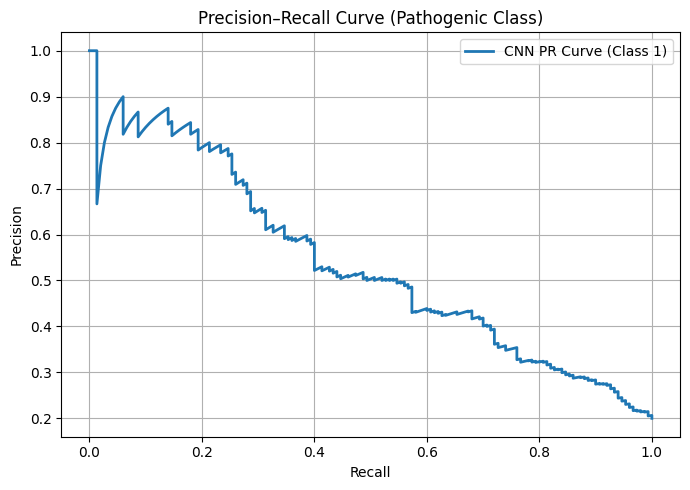

In [ ]:
# 1. Precision–Recall Curve for Class 1

precision, recall, _ = precision_recall_curve(cnn_labels, cnn_preds)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, lw=2, label="CNN PR Curve (Class 1)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Pathogenic Class)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


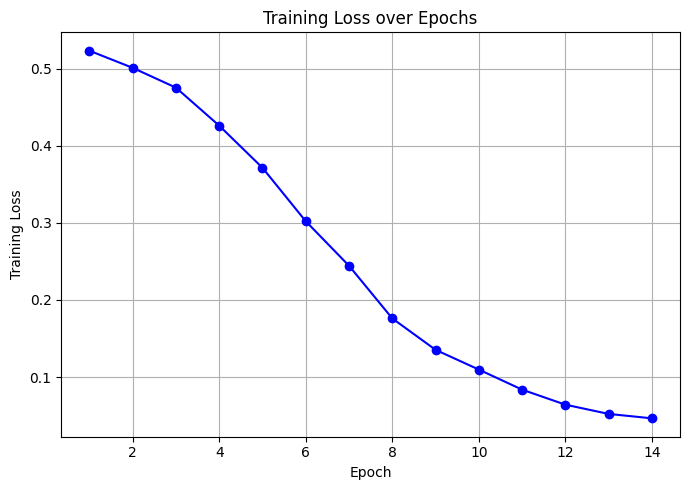

In [ ]:
# 2. Training Loss vs Epoch

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

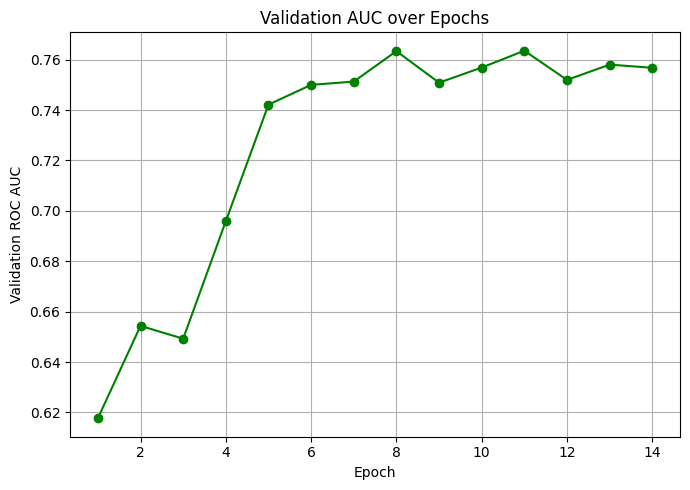

In [ ]:
# 3. Validation AUC vs Epoch

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(val_aucs) + 1), val_aucs, marker="o", color="green")
plt.xlabel("Epoch")
plt.ylabel("Validation ROC AUC")
plt.title("Validation AUC over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

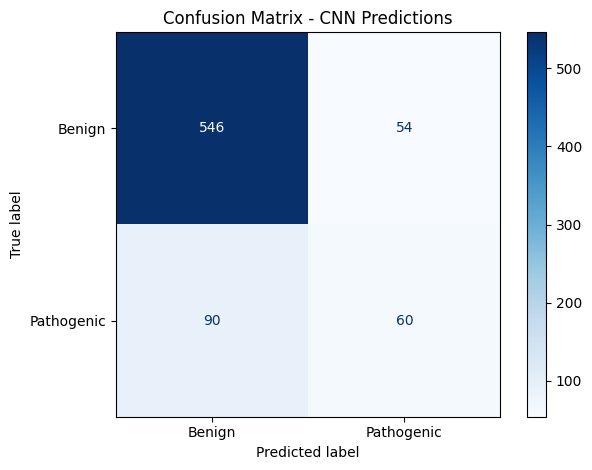

In [ ]:
# 4. Confusion Matrix – CNN

cnn_pred_labels = (cnn_preds > 0.5).astype(int)
cm_cnn = confusion_matrix(cnn_labels, cnn_pred_labels)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=["Benign", "Pathogenic"])

plt.figure(figsize=(6, 6))
disp_cnn.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - CNN Predictions")
plt.grid(False)
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

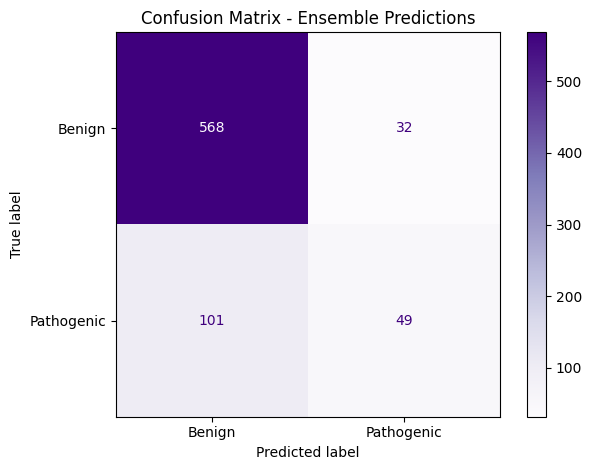

In [ ]:
# 5. Confusion Matrix – Ensemble

ensemble_pred_labels = (ensemble_preds > 0.5).astype(int)
cm_ensemble = confusion_matrix(ensemble_labels, ensemble_pred_labels)
disp_ens = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble, display_labels=["Benign", "Pathogenic"])

plt.figure(figsize=(6, 6))
disp_ens.plot(cmap="Purples", values_format="d")
plt.title("Confusion Matrix - Ensemble Predictions")
plt.grid(False)
plt.tight_layout()
plt.show()
